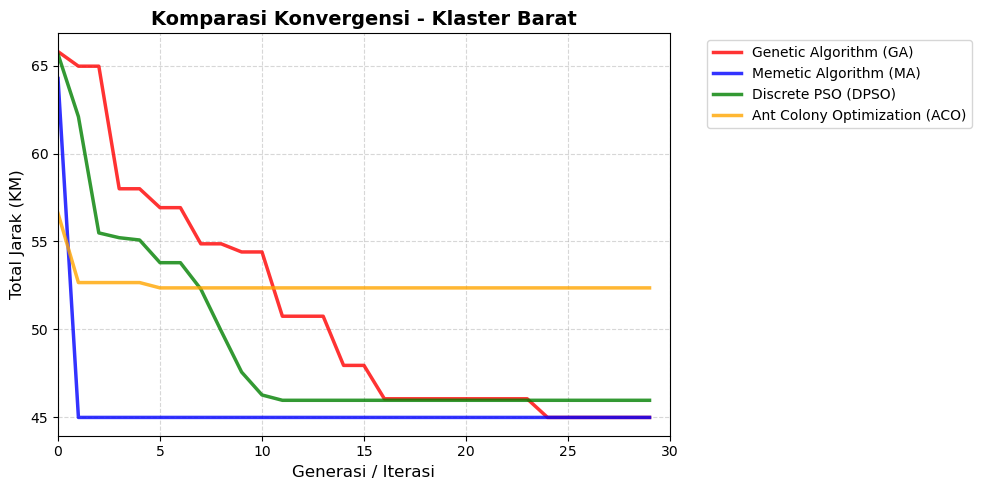

------------------------------------------------------------


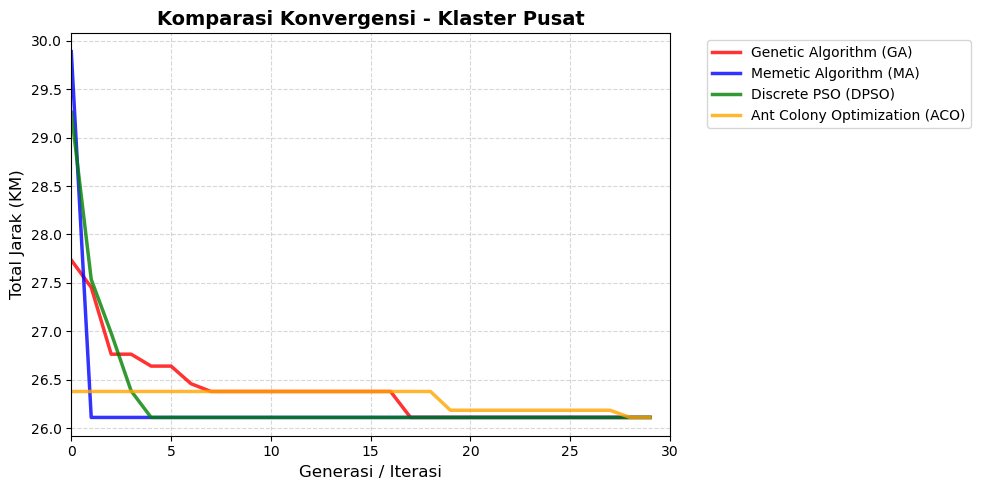

------------------------------------------------------------


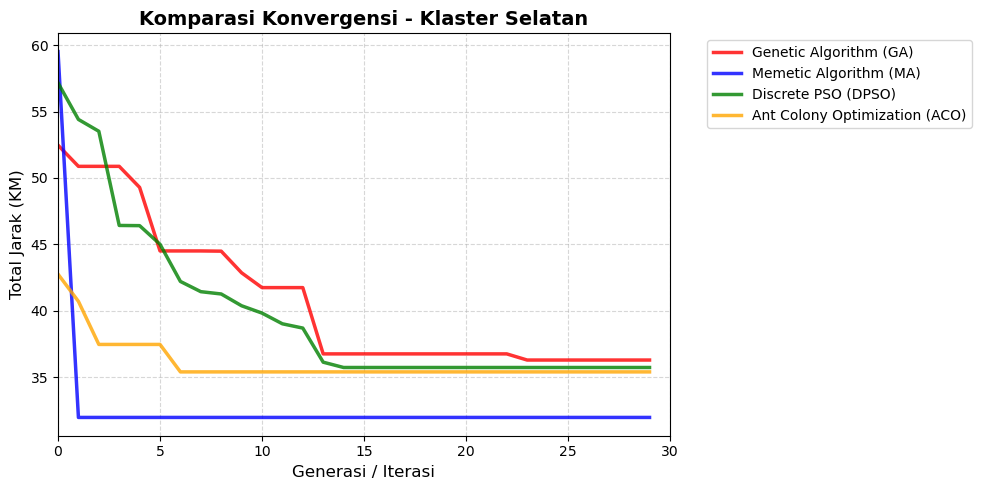

------------------------------------------------------------


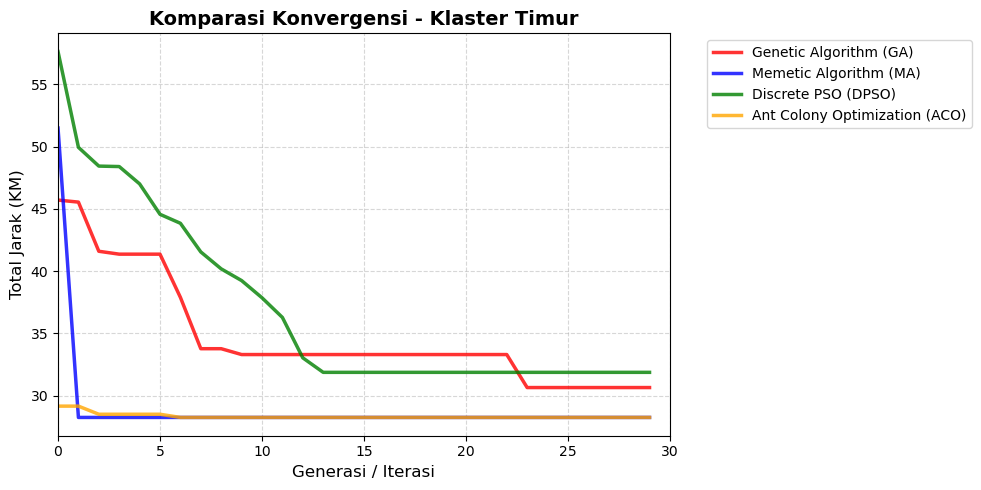

------------------------------------------------------------


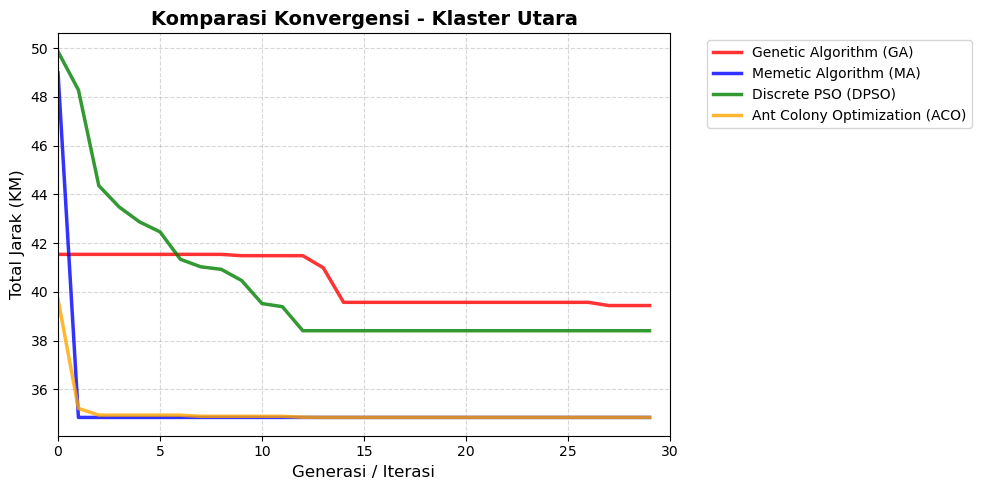

------------------------------------------------------------


In [5]:
import json
import matplotlib.pyplot as plt
import os

# 1. Daftar algoritma
algoritma_list = ['ga', 'ma', 'dpso', 'aco']
label_algo = {
    'ga': 'Genetic Algorithm (GA)', 
    'ma': 'Memetic Algorithm (MA)', 
    'dpso': 'Discrete PSO (DPSO)', 
    'aco': 'Ant Colony Optimization (ACO)'
}
warna_algo = {'ga': 'red', 'ma': 'blue', 'dpso': 'green', 'aco': 'orange'}
data_gabungan = {}

# 2. Buka brankas JSON (Dengan pengaman huruf besar/kecil)
for algo in algoritma_list:
    path_file = f'../output_json/rute_{algo}.json'
    if os.path.exists(path_file):
        with open(path_file, 'r') as f:
            data_mentah = json.load(f)
            data_gabungan[algo] = {k.lower(): v for k, v in data_mentah.items()}
    else:
        print(f"❌ File rute_{algo}.json tidak ditemukan!")

# 3. Looping untuk membuat grafik
klaster_list = ['barat', 'pusat', 'selatan', 'timur', 'utara']
batas_generasi = 30  # Mentok di iterasi 30 aja biar kelihatan jelas balapannya

for klaster in klaster_list:
    plt.figure(figsize=(10, 5))
    
    for algo in algoritma_list:
        if algo in data_gabungan and klaster in data_gabungan[algo]:
            riwayat_asli = data_gabungan[algo][klaster].get("riwayat_konvergensi", [])
            
            if len(riwayat_asli) > 0:
                
                # --- JALAN PINTAS 1: BIKIN MONOTON (OBAT UNTUK ACO) ---
                # Memastikan garis tidak pernah naik. Kalau nemu jarak yang lebih jelek, 
                # pakai jarak terbaik sebelumnya.
                riwayat_monoton = []
                best_so_far = float('inf')
                for jarak in riwayat_asli:
                    if jarak < best_so_far:
                        best_so_far = jarak
                    riwayat_monoton.append(best_so_far)
                
                # --- JALAN PINTAS 2: ANTI-BUNTUNG (OBAT UNTUK GA & DPSO) ---
                # Tarik ujung garis terakhir sampai menyentuh batas_generasi
                riwayat_plot = list(riwayat_monoton)
                if len(riwayat_plot) < batas_generasi:
                    riwayat_plot.extend([riwayat_plot[-1]] * (batas_generasi - len(riwayat_plot)))
                
                # Gambar grafiknya
                plt.plot(riwayat_plot[:batas_generasi], label=label_algo[algo], color=warna_algo[algo], linewidth=2.5, alpha=0.8)

    # 4. Percantik Grafik
    plt.title(f'Komparasi Konvergensi - Klaster {klaster.capitalize()}', fontsize=14, fontweight='bold')
    plt.xlabel('Generasi / Iterasi', fontsize=12)
    plt.ylabel('Total Jarak (KM)', fontsize=12)
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xlim(0, batas_generasi)
    
    plt.tight_layout()
    plt.show()
    print("-" * 60)